# Task 2.1: Dataset Selection and Setup
**Paper**: *Ensemble of Exemplar-SVMs for Object Detection and Beyond* — Malisiewicz, Gupta & Efros (ICCV 2011)

---

## Hyperparameters and Configuration

All hyperparameters are defined here in one place for reproducibility.

In [1]:
import numpy as np

# ===== RANDOM SEED =====
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ===== DATASET CONFIGURATION =====
N_SAMPLES = 500
N_FEATURES = 10
N_CLASSES = 2
N_INFORMATIVE = 10
N_REDUNDANT = 0
CLASS_SEP = 1.5          # well-separated classes for clean reproduction
TEST_SIZE = 0.3

print(f"Random seed: {RANDOM_SEED}")
print(f"Dataset: {N_SAMPLES} samples, {N_FEATURES} features, {N_CLASSES} classes")
print(f"Class separation: {CLASS_SEP}")
print(f"Train/Test split: {1 - TEST_SIZE:.0%} / {TEST_SIZE:.0%}")

Random seed: 42
Dataset: 500 samples, 10 features, 2 classes
Class separation: 1.5
Train/Test split: 70% / 30%


## Dataset Justification

We use `sklearn.datasets.make_classification` to generate a synthetic binary classification dataset with 500 samples and 10 features.

**Why this dataset is appropriate for the Exemplar-SVM method:**
The core contribution of the Exemplar-SVM paper is the idea of training a separate linear SVM for each positive exemplar, using that single positive against many negatives. This positive-vs-negative structure maps directly onto a binary classification problem: each positive sample becomes an 'exemplar' with its own SVM, trained against all samples from the opposite class. The synthetic dataset allows us to control class separability and noise, which is essential for both clean reproduction (Task 2.2) and ablation/failure analysis (Tasks 3.1, 3.2).

**Limitations compared to the original paper's dataset:**
The original paper uses the PASCAL VOC 2007 dataset with 12,608 exemplars across 20 object categories, where features are HOG descriptors computed from image windows in a sliding-window detection framework. Our dataset is dramatically simpler: it has only 500 samples with raw feature vectors, no spatial structure, no sliding window, and no HOG computation. This means we cannot reproduce aspects like non-maximum suppression, exemplar co-occurrence scoring, or meta-data transfer. However, it preserves the core algorithmic contribution — per-exemplar discriminative training with calibration.

## Dataset Generation and Preprocessing

In [2]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Generate dataset
X, y = make_classification(
    n_samples=N_SAMPLES,
    n_features=N_FEATURES,
    n_informative=N_INFORMATIVE,
    n_redundant=N_REDUNDANT,
    n_classes=N_CLASSES,
    class_sep=CLASS_SEP,
    random_state=RANDOM_SEED
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)

# Standardise features (analogous to HOG normalisation in the paper)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} samples ({(y_train == 1).sum()} positive, {(y_train == 0).sum()} negative)")
print(f"Test set:     {X_test.shape[0]} samples ({(y_test == 1).sum()} positive, {(y_test == 0).sum()} negative)")
print(f"Feature dimensionality: {X_train.shape[1]}")

Training set: 350 samples (176 positive, 174 negative)
Test set:     150 samples (75 positive, 75 negative)
Feature dimensionality: 10


**What the code above does**: We generate a synthetic binary classification dataset, split it into training (70%) and test (30%) sets with stratification, and standardise the features to zero mean and unit variance. Standardisation is analogous to the HOG normalisation performed in the original paper (Section 3, footnote 1).

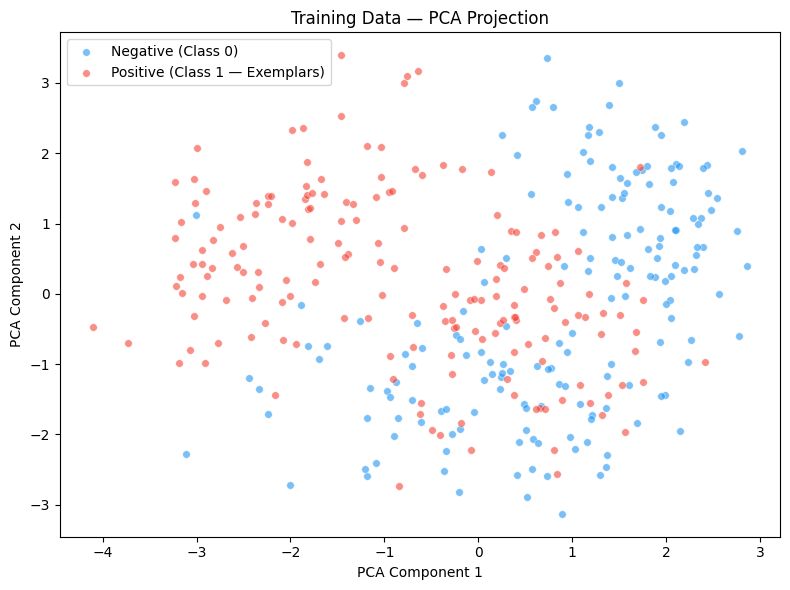

Saved: results/task_2_1_dataset_pca.png


In [3]:
# Visualise the first two PCA components of the dataset
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_train_2d = pca.fit_transform(X_train)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
colors = ['#2196F3', '#F44336']
for cls in [0, 1]:
    mask = y_train == cls
    label = 'Negative (Class 0)' if cls == 0 else 'Positive (Class 1 — Exemplars)'
    ax.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1], c=colors[cls],
               alpha=0.6, s=30, label=label, edgecolors='white', linewidths=0.5)
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_title('Training Data — PCA Projection')
ax.legend()
plt.tight_layout()

os.makedirs('results', exist_ok=True)
fig.savefig('results/task_2_1_dataset_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/task_2_1_dataset_pca.png")

**What the code above does**: We use PCA to project the 10-dimensional training data into 2D for visualisation. This confirms that the two classes are reasonably separated, making this a suitable testbed for the Exemplar-SVM method. In the original paper, Figure 2 illustrates the decision boundaries of per-exemplar SVMs; this visualisation serves a similar purpose for our simplified setting.